# Do diverse topic ties predict concept spread? The co-occurrence screen (D and F vs. B5)

This notebook demos **experiment 3** of the research run: a pre-registered **screen** of two co-occurrence emergence
indicators on the frozen **P78 dev panel** under the shared protocol **S0**.

* **D (structural diversity):** how many distinct backbone communities a new concept's topic neighbours span,
  relative to a frequency-matched null. The primary D is `D_ratio`, the pre-declared fallback after the literal
  `D_z` failed the size diagnostic.
* **F (frequency-free selectivity):** `F_res`, which asks whether a concept ties to topics more than their
  background prevalence would predict.
* **B5 baseline:** log early volume, growth, off-home share, venue-field entropy and the number of fields.
* **Main outcome:** `O2r`, the rarefied breadth of venue fields the concept reaches later. Binary outcomes `O1`, `O3`
  and `O2r_top` and field-level `R_j` are secondary.

**What the original `method.py` does.** It orchestrates 9 steps. Steps 1-6 fetch S0 yearly counts from the OpenAlex
API, scan all **476M works** of the OpenAlex S3 snapshot, build a full-corpus topic-PMI backbone with Leiden
communities, and compute ego-network features. That takes hours and a snapshot of several hundred GB, so this notebook
**starts from the cached per-concept tables that those steps wrote** (`mini_demo_data.json`: 78 panel concepts, 47 of
which pass the dev filters). It then runs **step 7, `screen.py`**, the statistical core of the experiment, in full:

1. leave-one-home-field-group-out (LOGO) ridge and logistic prediction of the outcomes from B5 vs. B5 + candidate;
2. a stratified concept bootstrap for the delta-rho / delta-AUC confidence intervals;
3. the pre-registered selection rule, the dissociation tests, portability of about 30 indicators, and the
   sensitivity analyses.

The code below is copied from `method.py`, `config.py` and `screen.py` with minimal changes: the CSVs are read from
the loaded JSON, `main()` is split into cells, and the bootstrap process pool uses `fork` so that notebook-defined
workers can be pickled. The bootstrap runs at the original 2,000 resamples, with 2 worker processes instead of 4 to
match Colab's 2 CPU cores. The whole notebook takes about 2-3 minutes and reproduces the full run's numbers exactly.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# ---- original screen.py import block (as-is)
from __future__ import annotations

import os

for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # tiny models: avoid BLAS thread oversubscription across bootstrap workers

import json
import math
import multiprocessing as mp
import sys
import warnings
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ---- original method.py / config.py imports used below
import time
from pathlib import Path

# ---- additional imports for the notebook (visualisation)
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-1/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("concepts in panel:", len(data["examples"]))

P78 panel (78 concepts; 47 pass the S0 dev filters) with the cached per-concept tables produced by steps 1-6 of method.py (S0 outcomes, ego-network features, field-level outcomes/features, split-half reliability draws). Source: results/*.csv of gen_art_experiment_3.
concepts in panel: 78


## Configuration

**Tunable parameters.** The only expensive part of the screen is the bootstrap. The original uses
`N_BOOT = 2000` concept resamples for the main screen. The reach30 hurdle and the five sensitivity analyses each use
`min(1000, n_boot)` resamples, and `n_workers = 4` processes run them. Every resample refits the whole LOGO, which is
about 90 small models. The demo keeps the **original `N_BOOT = 2000`**, which takes about 2 minutes on 2 cores.
Lower it (e.g. to 200) for a faster run. Point estimates do not depend on `N_BOOT`; only the width and stability of
the confidence intervals do, and with fewer than 20 resamples the CIs are reported as NaN.

The rest of the cell is copied from the original `config.py`: frozen protocol constants and output paths, which are
now relative to the notebook.

In [5]:
# ---------------------------------------------------------------- demo-tunable parameters
N_BOOT = 2000      # bootstrap resamples for the main screen   (original: 2000 -> config.N_BOOT; minimum useful: 20)
N_WORKERS = 2      # bootstrap worker processes               (original: 4 -> method.py --workers; Colab has 2 cores)
SEED = 20260928    # bootstrap seed                             (original: 20260928, unchanged)

# ---------------------------------------------------------------- frozen S0 constants (verbatim from config.py)
DEV_FIELDS = {17: "Computer Science", 22: "Engineering", 13: "Biochemistry, Genetics and Molecular Biology",
              27: "Medicine"}
GROUP_SHORT = {17: "CS", 22: "ENG", 13: "BIO", 27: "MED"}
DEV_T0 = (2003, 2009)
RAREFY_M = 30
DROPPED_ALIASES = [{"concept": "natural orifice transluminal endoscopic surgery", "alias": "NOTES",
                    "reason": "common English word; case-insensitive stemmed phrase search would match 'notes'"}]

# paths (config.py derives them from its own location; here: relative to the notebook's working directory)
ROOT = Path(".").resolve()
RES = ROOT / "results"
LOGS = ROOT / "logs"
for _d in (RES, LOGS):
    _d.mkdir(parents=True, exist_ok=True)

## The pipeline orchestrated by `method.py`

`method.py` holds the list of pipeline steps and the full record of **deviations** from the pre-registered plan. It
writes the deviations to `results/deviations.json`, and they explain several design choices you will see in the
screen: `D_ratio` replaces `D_z` as the primary D, the Leiden gamma rule changed, and compositions use title-matched
works. The constants are copied verbatim below.

The original `run()` / `main()` call each step as a subprocess (`python <step>.py`). Here steps 1-6 are replaced by
their cached outputs, step 7 (`screen`) runs inline below, and steps 8-9 (exploratory partial association and
figures / `method_out.json`) are replaced by the summary cell at the end.

In [6]:
STEPS = ["s0_fetch", "snapshot_meta", "scan_snapshot", "s0_outcomes", "backbone", "features", "screen",
         "extra_analyses", "make_outputs"]

DEVIATIONS = DROPPED_ALIASES + [
    {"id": "API_KEY_EXHAUSTED", "what": "The shared OpenAlex key had 0 credits left (x-ratelimit-remaining=0, reset "
     "~11.7 h) when this artifact started. API use was limited to the S0 yearly counts (78 concepts + global + OR test, "
     "156 credits in total) on the public per-IP anonymous pool (1,000/day; >= 800 left for siblings).",
     "consequence": "All other data (venue windows, ego networks, backbone, background prevalence) come from the free "
     "OpenAlex S3 works snapshot (2026-09-23; 476M works) at 0 credits."},
    {"id": "TITLE_GROUNDING_FOR_COMPOSITION", "what": "Venue-field compositions (home field, O2r, R_j, early "
     "off-home share/entropy/reach) and ego topic counts use TITLE-matched base works from the snapshot "
     "(OpenAlex-like analysis: lowercase, possessive strip, stop words with position gaps, Porter stemming, "
     "positional phrase match), not title+abstract matches, because abstracts are 43% of the snapshot bytes. "
     "t0, newborn, O1, O3, log volume and growth use the S0-exact API title+abstract counts.",
     "consequence": "Lower recall (see sanity.median_title_share_of_api_early), higher topical precision; field "
     "compositions are estimated from the papers that name the concept in the title."},
    {"id": "HOME_WINDOW_WIDENED", "what": "If fewer than 5 labelled title-matched papers exist in t0..t0+1, the home "
     "field is decided on t0..t0+2 (flag home_window in outcomes.csv)."},
    {"id": "FULL_CORPUS_BACKBONE", "what": "The backbone uses ALL base works of each slice (millions) instead of "
     "10k-work samples, and exact yearly background prevalence instead of slice-level log-linear interpolation "
     "(plan departures 2 and 3 are removed)."},
    {"id": "GAMMA_RULE", "what": "On the dense full-corpus backbone the plan's rule (gamma maximising median standard "
     "modularity) picks gamma=1, which leaves only ~8 communities of ~500 topics, outside the plan's expected 'tens to a "
     "few hundred' (T2). BEFORE any outcome was inspected, the primary gamma was redefined as the highest-median-Q gamma "
     "whose median number of non-trivial communities is >= 20; the plan-rule partition is reported as D_q."},
    {"id": "SELF_TOPIC_LEXICAL_RULE", "what": "A literal 'shares one content lemma' rule flagged generic topics as "
     "SELF (e.g. 'cell' -> 30 topics for iPSC, 'sensing' -> Remote Sensing for compressed sensing, 'comparative' -> "
     "legal studies). The lexical SELF rule was tightened (before outcomes were inspected) to: the topic name contains "
     "ALL content lemmas (lemma occurring in <= 100 topic names) of at least one of the concept's phrases; the >= 20% "
     "paper-share rule is unchanged. 16 of 47 dev concepts get a lexical self topic (e.g. compressed sensing -> "
     "'Sparse and Compressive Sensing Techniques')."},
    {"id": "D_PRIMARY_FALLBACK_T3", "what": "T3 STOP-AND-FIX fired: 70% of dev concepts have D_z < -5 and "
     "Spearman(D_z, M) = -0.69 (with log early volume -0.63): the frequency-matched null draws from all of science "
     "while real neighbours are topically concentrated, so z scales with M. Per the plan's pre-stated fallback, and "
     "decided on outcome-blind diagnostics only, the primary D is the one of D_ratio / D_rare with the smaller "
     "|Spearman| with M: D_ratio (obs distinct communities / null mean; 0.23 vs 0.29). D_z is still screened and "
     "reported as 'D_z_literal' (not ranked)."},
    {"id": "SPLIT_HALF_PAPER_LEVEL", "what": "Split-half reliability uses real paper-level random halves (paper topic "
     "lists are available from the snapshot) instead of binomial thinning of aggregate counts (plan departure 7)."},
    {"id": "EGO_WINDOWS_EXACT", "what": "Ego windows are exact paper sets per year, so first-appearance years of new "
     "neighbours are yearly (plan departure 4 no longer binds)."},
    {"id": "CENTRALITY_ON_KNN_BACKBONE", "what": "Betweenness/k-core/constraint of the inserted concept node are "
     "computed on a kNN-sparsified (top-10 PMI edges per topic), unweighted copy of the slice backbone, for runtime."},
    {"id": "COMPRESSED_SENSING_ALIAS", "what": "The OR-syntax test showed 'compressed sensing' and 'compressive "
     "sensing' return identical counts (same Porter stem), so the alias adds nothing; the pipe syntax was frozen."},
]

(RES / "deviations.json").write_text(json.dumps(DEVIATIONS, indent=1))
for i, s in enumerate(STEPS, 1):
    print(f"{i}. {s:15s} {'<- runs in this notebook' if s == 'screen' else '(cached output loaded)' if i <= 6 else '(summarised at the end)'}")
print("\ndeviations:", [d.get("id", "DROPPED_ALIAS:" + d.get("alias", "")) for d in DEVIATIONS])

1. s0_fetch        (cached output loaded)
2. snapshot_meta   (cached output loaded)
3. scan_snapshot   (cached output loaded)
4. s0_outcomes     (cached output loaded)
5. backbone        (cached output loaded)
6. features        (cached output loaded)
7. screen          <- runs in this notebook
8. extra_analyses  (summarised at the end)
9. make_outputs    (summarised at the end)

deviations: ['DROPPED_ALIAS:NOTES', 'API_KEY_EXHAUSTED', 'TITLE_GROUNDING_FOR_COMPOSITION', 'HOME_WINDOW_WIDENED', 'FULL_CORPUS_BACKBONE', 'GAMMA_RULE', 'SELF_TOPIC_LEXICAL_RULE', 'D_PRIMARY_FALLBACK_T3', 'SPLIT_HALF_PAPER_LEVEL', 'EGO_WINDOWS_EXACT', 'CENTRALITY_ON_KNN_BACKBONE', 'COMPRESSED_SENSING_ALIAS']


## Rebuild the cached input tables

`screen.py` reads five CSVs from `results/`, the outputs of steps 4-6. Here each is rebuilt as a DataFrame from the
per-concept records in `data`, with the same columns in the same order:

| table | rows | content |
|---|---|---|
| `outcomes.csv` | 78 concepts | S0 onset `t0`, home field/group, outcomes `O1 O2r O3 reach30`, B5 covariates, drop reason |
| `features_ego.csv` | 47 dev concepts | ~45 ego-network indicators (`D_*`, `F_*`, NOV, degree, betweenness, ...) |
| `field_outcomes_base.csv` | 129 (concept, field) rows | field-level entry outcome `R_j` and field baseline covariates |
| `field_features.csv` | 129 rows | field-level `Dj`, `Fj`, `Fj_missing` |
| `reliability_splits.csv` | 47 x 50 splits | paper-level split-half values of `D_z`, `D_ratio`, `F_res` |

In [7]:
cols = data["columns"]
ex = data["examples"]
# replaces pd.read_csv(RES / "<table>.csv") in screen.main()
out_tbl = pd.DataFrame([e["outcomes"] for e in ex], columns=cols["outcomes"])
fe_tbl = pd.DataFrame([e["ego_features"] for e in ex if e["ego_features"] is not None], columns=cols["ego_features"])
fo_tbl = pd.DataFrame([r for e in ex for r in e["field_outcomes"]], columns=cols["field_outcomes"])
ff_tbl = pd.DataFrame([r for e in ex for r in e["field_features"]], columns=cols["field_features"])
rel_tbl = pd.DataFrame([r for e in ex for r in e["reliability_splits"]], columns=cols["reliability_splits"])
for name, t in [("outcomes", out_tbl), ("features_ego", fe_tbl), ("field_outcomes_base", fo_tbl),
                ("field_features", ff_tbl), ("reliability_splits", rel_tbl)]:
    print(f"{name:20s} {t.shape}")
out_tbl[["concept", "panel_group", "dropped_reason", "t0", "home", "O2r", "O1", "logvol", "entropy"]].head(8)

outcomes             (78, 32)
features_ego         (47, 48)
field_outcomes_base  (129, 10)
field_features       (129, 5)
reliability_splits   (2350, 8)


,concept,panel_group,dropped_reason,t0,home,O2r,O1,logvol,entropy
0,zinc finger nuclease,Biochem/Genetics,None,2005,13,4.188041,1.0,5.049856,0.362275
1,Web 2.0,CS/AI,home_outside_dev:33,2006,33,NaN,NaN,NaN,NaN
2,sentiment analysis,CS/AI,None,2007,17,4.556281,1.0,5.831882,0.965748
3,biosimilar,Medicine,None,2006,27,4.791850,1.0,6.018593,0.786097
4,smart grid,Engineering,None,2008,22,3.743934,0.0,8.227376,0.896017
5,cancer stem cell,Biochem/Genetics,None,2003,13,3.226035,1.0,6.787845,0.967450
6,cardiac resynchronization therapy,Medicine,t0_outside_dev_cohort,2002,None,NaN,NaN,NaN,NaN
7,crowdsourcing,CS/AI,None,2008,17,8.828446,1.0,6.871091,1.766229


## Models: standardised ridge, exact penalised logistic regression, LOGO

These are copied verbatim from `screen.py`.

* `_prep` median-imputes missing candidate values with the **training-fold** median, adds a missing-indicator
  column, and standardises on the training fold.
* `ridge_fit_predict` is closed-form ridge (alpha = 1), used for the continuous outcome `O2r`.
* `logit_newton` is the exact minimiser of the sklearn `LogisticRegression(C=1)` objective, solved by Newton-Raphson.
  It is faster and deterministic, and the sklearn reference is kept for the equivalence check.
* `logo` does leave-one-home-field-group-out: train on 3 of {BIO, CS, ENG, MED} and predict the 4th, so a
  candidate must transfer across fields.
* The metrics are Spearman rho (`srho`) for `O2r` and ROC-AUC (`auc`) for binary outcomes.

In [8]:
B5 = ["logvol", "growth", "offhome_share", "entropy", "nfields2"]
BF = ["logn_j_early", "growth_j", "share_j"]
# D: the plan's literal primary D_z failed the T3 STOP-AND-FIX size diagnostic (70% of D_z < -5,
# Spearman(D_z, M) = -0.69, with log volume -0.63; computed before any outcome was inspected), so the pre-declared
# fallback (the one of D_ratio / D_rare with the smaller |Spearman| with M) is primary: D_ratio (0.23 vs 0.29).
# D_z is still screened and reported as 'D_z_literal'.
PRIMARY = {"D": "D_ratio", "F": "F_res", "D_z_literal": "D_z"}
SCREENED = ("D", "F")
warnings.filterwarnings("ignore")


# ----------------------------------------------------------------------------- models
def _prep(Xtr: np.ndarray, Xte: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Median-impute (train medians) + missing flags for columns with NaN, then standardise on train."""
    Xtr = Xtr.astype(float).copy()
    Xte = Xte.astype(float).copy()
    flags_tr, flags_te = [], []
    for j in range(Xtr.shape[1]):
        mtr, mte = np.isnan(Xtr[:, j]), np.isnan(Xte[:, j])
        if mtr.any() or mte.any():
            med = np.nanmedian(Xtr[:, j]) if (~mtr).any() else 0.0
            Xtr[mtr, j] = med
            Xte[mte, j] = med
            if mtr.any() and (~mtr).any():
                flags_tr.append(mtr.astype(float))
                flags_te.append(mte.astype(float))
    if flags_tr:
        Xtr = np.column_stack([Xtr] + flags_tr)
        Xte = np.column_stack([Xte] + flags_te)
    mu = Xtr.mean(0)
    sd = Xtr.std(0)
    sd[sd == 0] = 1.0
    return (Xtr - mu) / sd, (Xte - mu) / sd


def ridge_fit_predict(Xtr, ytr, Xte, alpha: float = 1.0) -> np.ndarray:
    Xtr, Xte = _prep(Xtr, Xte)
    ym = ytr.mean()
    A = Xtr.T @ Xtr + alpha * np.eye(Xtr.shape[1])
    beta = np.linalg.solve(A, Xtr.T @ (ytr - ym))
    return ym + Xte @ beta


def logit_newton(X: np.ndarray, y: np.ndarray, C: float = 1.0, iters: int = 100, tol: float = 1e-10) -> np.ndarray:
    """Exact minimiser of 0.5*||w||^2 + C*sum(logloss) with an unpenalised intercept (the sklearn
    LogisticRegression(C=1) objective), by Newton-Raphson; returns [b, w]."""
    n, p = X.shape
    Z = np.column_stack([np.ones(n), X])
    beta = np.zeros(p + 1)
    R = np.eye(p + 1) / C
    R[0, 0] = 0.0
    for _ in range(iters):
        eta = Z @ beta
        mu = 1.0 / (1.0 + np.exp(-eta))
        g = Z.T @ (mu - y) + R @ beta
        H = (Z * (mu * (1 - mu))[:, None]).T @ Z + R + 1e-12 * np.eye(p + 1)
        step = np.linalg.solve(H, g)
        beta -= step
        if np.abs(step).max() < tol:
            break
    return beta


def logit_fit_predict(Xtr, ytr, Xte) -> np.ndarray:
    if len(np.unique(ytr)) < 2:
        return np.full(len(Xte), ytr.mean())
    Xtr, Xte = _prep(Xtr, Xte)
    beta = logit_newton(Xtr, ytr.astype(float))
    return 1.0 / (1.0 + np.exp(-(beta[0] + Xte @ beta[1:])))


def logit_fit_predict_sklearn(Xtr, ytr, Xte) -> np.ndarray:
    """Reference implementation (used only in the equivalence check)."""
    Xtr, Xte = _prep(Xtr, Xte)
    m = LogisticRegression(C=1.0, max_iter=5000, tol=1e-10)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]


def logo(X: np.ndarray, y: np.ndarray, groups: np.ndarray, kind: str) -> np.ndarray:
    oof = np.full(len(y), np.nan)
    for g in np.unique(groups):
        te = groups == g
        tr = ~te
        if tr.sum() < 5:
            continue
        f = ridge_fit_predict if kind == "ridge" else logit_fit_predict
        oof[te] = f(X[tr], y[tr], X[te])
    return oof


def srho(a, b) -> float:
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3 or np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return float("nan")
    return float(spearmanr(a[m], b[m]).statistic)


def auc(y, p) -> float:
    m = np.isfinite(p) & np.isfinite(y)
    if m.sum() < 3 or len(np.unique(y[m])) < 2:
        return float("nan")
    return float(roc_auc_score(y[m], p[m]))

## One evaluation: concept level and field level

`eval_concept` fits B5 and B5 + candidate under **identical LOGO folds** for each outcome. For each candidate it
returns the base metric and the **delta** (delta-rho for `O2r`, delta-AUC for binary outcomes), plus per-group
deltas and out-of-fold predictions when `per_group=True`. `eval_field` does the same for the 129 (concept, field) rows
that predict field entry `R_j`, with the field baseline `BF`. Both are copied verbatim.

In [9]:
def eval_concept(df: pd.DataFrame, cands: list[str], base_cols: list[str], outcomes: dict[str, str],
                 per_group: bool = False) -> dict:
    """Returns {outcome: {'base': metric, cand: delta, ...}} (+ per-group deltas for continuous outcomes)."""
    res = {}
    g = df["group"].to_numpy()
    for oname, kind in outcomes.items():
        d = df[np.isfinite(df[oname].to_numpy(dtype=float))]
        if len(d) < 8:
            continue
        y = d[oname].to_numpy(dtype=float)
        gg = d["group"].to_numpy()
        Xb = d[base_cols].to_numpy(dtype=float)
        pb = logo(Xb, y, gg, "ridge" if kind == "cont" else "logit")
        metric = srho if kind == "cont" else auc
        mb = metric(pb, y) if kind == "cont" else metric(y, pb)
        r = {"base": mb}
        for c in cands:
            Xc = d[base_cols + [c]].to_numpy(dtype=float)
            pc_ = logo(Xc, y, gg, "ridge" if kind == "cont" else "logit")
            mc = metric(pc_, y) if kind == "cont" else metric(y, pc_)
            r[c] = mc - mb
            if per_group:
                pg = {}
                for grp in np.unique(gg):
                    m = gg == grp
                    if kind == "cont":
                        pg[grp] = srho(pc_[m], y[m]) - srho(pb[m], y[m])
                    else:
                        pg[grp] = auc(y[m], pc_[m]) - auc(y[m], pb[m])
                r[c + "__per_group"] = pg
                r[c + "__oof"] = pc_.tolist()
        if per_group:
            r["base__oof"] = pb.tolist()
            r["index"] = d["concept"].tolist()
        res[oname] = r
    del g
    return res


def eval_field(fdf: pd.DataFrame, cands: list[list[str]]) -> dict:
    y = fdf["R_j"].to_numpy(dtype=float)
    gg = fdf["group"].to_numpy()
    pb = logo(fdf[BF].to_numpy(dtype=float), y, gg, "logit")
    r = {"base": auc(y, pb)}
    for cc in cands:
        pc_ = logo(fdf[BF + cc].to_numpy(dtype=float), y, gg, "logit")
        r["+".join(cc)] = auc(y, pc_) - r["base"]
    return r

## Stratified concept bootstrap

Each resample draws **concepts with replacement within each home group**, so every group keeps its n. It then
**refits the entire LOGO**. Field rows are resampled cluster-wise: a drawn concept brings all its field rows. Seeds
are split into chunks and run in a process pool.

*Notebook fix (the only logic change):* the original uses `mp.get_context("spawn")`. Spawned workers re-import
`__main__`, which in a notebook does not contain `_boot_worker`, so the pool uses `"fork"` (Linux / Colab) instead.
The results are the same because each resample is seeded independently.

In [10]:
def strat_resample(df: pd.DataFrame, rng) -> pd.DataFrame:
    parts = []
    for _, d in df.groupby("group"):
        idx = rng.integers(0, len(d), len(d))
        parts.append(d.iloc[idx])
    return pd.concat(parts, ignore_index=True)


def _boot_worker(args):
    df, fdf, cands, base_cols, outcomes, field_cands, seeds = args
    out = []
    for sd in seeds:
        rng = np.random.default_rng(int(sd))
        bdf = strat_resample(df, rng)
        r = {"concept": eval_concept(bdf, cands, base_cols, outcomes)}
        if fdf is not None:
            # concept-clustered: resample concepts within group, take all their field rows
            parts = []
            for c in bdf["concept"]:
                parts.append(fdf[fdf.concept == c])
            bf = pd.concat(parts, ignore_index=True) if parts else fdf.iloc[:0]
            r["field"] = eval_field(bf, field_cands) if len(bf) > 10 else {}
        out.append(r)
    return out


def bootstrap(df, fdf, cands, base_cols, outcomes, field_cands, n_boot, seed, n_workers=4):
    seeds = np.random.default_rng(seed).integers(0, 2**31 - 1, n_boot)
    chunks = np.array_split(seeds, n_workers * 4)
    res = []
    # notebook fix: "fork" instead of "spawn" (spawned workers cannot import functions defined in a notebook)
    with ProcessPoolExecutor(n_workers, mp_context=mp.get_context("fork")) as ex:
        for part in ex.map(_boot_worker, [(df, fdf, cands, base_cols, outcomes, field_cands, ch) for ch in chunks]):
            res.extend(part)
    return res


def ci(vals, lo, hi):
    v = np.asarray([x for x in vals if x is not None and np.isfinite(x)])
    if len(v) < 20:
        return [float("nan"), float("nan")]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]

## Reliability, diagnostics and the pre-registered selection rule

* `reliability` computes the Spearman-Brown-corrected split-half reliability of a candidate from 50 paper-level
  random halves.
* `kendall_w` measures agreement of indicator rankings across the 4 home groups (portability).
* `estimable` checks whether a binary outcome is testable under LOGO; it needs positives and negatives in at least 2
  groups each.
* `selection` is the **pre-registered rule**. A candidate survives only if delta-rho >= 0.10, the 90% CI lower bound
  is > 0, delta-rho is positive in >= 3 of 4 groups, SB >= 0.6, and |rho| with log volume and with growth is <= 0.6.

In [11]:
def reliability(rel: pd.DataFrame, col: str, concepts: list[str]) -> dict:
    rs = []
    rel = rel[rel.concept.isin(concepts)]
    for _, d in rel.groupby("split"):
        a, b = d[f"{col}_A"].to_numpy(float), d[f"{col}_B"].to_numpy(float)
        r = srho(a, b)
        if np.isfinite(r):
            rs.append(r)
    if not rs:
        return {"SB_median": float("nan")}
    rs = np.array(rs)
    sb = 2 * rs / (1 + rs)
    return {"r_half_median": float(np.median(rs)), "SB_median": float(np.median(sb)),
            "SB_IQR": [float(np.percentile(sb, 25)), float(np.percentile(sb, 75))], "n_splits": int(len(rs)),
            "method": "paper-level random halves of each concept's title-matched works (t0-3..t0+4), 200 null draws"}


def kendall_w(mat: np.ndarray) -> float:
    """mat: raters x items (scores); W over rankings of items, raters = groups."""
    mat = mat[:, np.all(np.isfinite(mat), axis=0)]
    m, n = mat.shape
    if n < 3 or m < 2:
        return float("nan")
    ranks = np.array([pd.Series(row).rank().to_numpy() for row in mat])
    R = ranks.sum(0)
    S = ((R - R.mean()) ** 2).sum()
    return float(12 * S / (m ** 2 * (n ** 3 - n)))


# ----------------------------------------------------------------------------- main
INDICATORS = ["D_z", "D_ratio", "D_rare", "D_sub", "D_lag", "D_withself", "D_q", "M", "F_res", "F_z", "F_bg",
              "F_obs_growth", "NOV", "NOV_res", "deg_growth", "str_growth", "new_edge_rate", "edge_persistence",
              "turnover", "participation", "n_comm_W3", "comm_transitions", "ego_density_change", "btw_t0", "btw_t4",
              "btw_change", "kcore_t4", "constraint_t4", "constraint_change"] + B5


def estimable(df: pd.DataFrame, o: str) -> bool:
    """A binary outcome is LOGO-estimable only if positives and negatives occur in >= 2 home groups each."""
    d = df[df[o].notna()]
    pos = d[d[o] == 1].group.nunique()
    neg = d[d[o] == 0].group.nunique()
    return pos >= 2 and neg >= 2


def selection(c: dict) -> dict:
    crit = {"delta_rho>=0.10": c["delta_rho"] >= 0.10,
            "CI90_low>0": c["CI90"][0] > 0,
            ">=3/4 groups positive": c["n_groups_positive"] >= 3,
            "SB>=0.6": (c["reliability"].get("SB_median", float("nan")) or 0) >= 0.6,
            "|rho_logvol|<=0.6": abs(c["rho_logvol"]) <= 0.6,
            "|rho_growth|<=0.6": abs(c["rho_growth"]) <= 0.6}
    crit = {k: bool(v) if v == v else False for k, v in crit.items()}
    return {"criteria": crit, "survives": all(crit.values())}

## `screen.main()`, part 1: assemble the dev set

From here the cells are the body of `screen.main(n_boot, seed, n_workers)`, split into steps. First the 47 **dev
concepts** are kept: those with no drop reason, i.e. `t0` in 2003-2009 and a home field in CS, ENG, BIO or MED. They
are merged with their ego features and the field-level table is assembled. `O2r_top` is then defined as the top
tercile of `O2r`.

In [12]:
n_boot, seed, n_workers, tag = N_BOOT, SEED, N_WORKERS, ""
_t_screen = time.time()
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(LOGS / "screen.log", rotation="30 MB", level="DEBUG")
out = out_tbl.copy()        # original: pd.read_csv(RES / "outcomes.csv")
fe = fe_tbl.copy()          # original: pd.read_csv(RES / "features_ego.csv")
dev = out[out.dropped_reason.isna() | (out.dropped_reason == "")].merge(fe, on="concept", how="left")
dev["group"] = dev["group_id"].map(GROUP_SHORT)
feats_cols = ["concept", "t0", "newborn", "group"] + B5 + [c for c in fe.columns if c != "concept"]
dev[feats_cols].to_csv(RES / "features.csv", index=False)
# field-level table
fo = fo_tbl.copy()          # original: pd.read_csv(RES / "field_outcomes_base.csv")
ff = ff_tbl.copy()          # original: pd.read_csv(RES / "field_features.csv")
fdf = fo.merge(ff, on=["concept", "field"], how="left")
fdf["group"] = fdf["group"].map({v: GROUP_SHORT[k] for k, v in DEV_FIELDS.items()})
fdf = fdf.merge(dev[["concept", "D_z", "D_ratio", "F_res"]], on="concept", how="left")
fdf.to_csv(RES / "field_outcomes.csv", index=False)
# O2r top tercile (within the dev set with O2r)
q = dev["O2r"].quantile(2 / 3)
dev["O2r_top"] = np.where(dev["O2r"].notna(), (dev["O2r"] >= q).astype(float), np.nan)
main_df = dev[dev["O2r"].notna()].reset_index(drop=True)
for c in ("O1", "O3", "reach30"):
    dev[c] = dev[c].astype(float)
n_main = len(main_df)
logger.info(f"dev concepts: {len(dev)}  with O2r: {n_main}  groups: {main_df.group.value_counts().to_dict()}  "
            f"field rows: {len(fdf)}")

21:10:41|INFO   |dev concepts: 47  with O2r: 47  groups: {'BIO': 16, 'CS': 12, 'MED': 10, 'ENG': 9}  field rows: 129


## Part 2: point estimates

These are the headline numbers. The B5 baseline's LOGO rho with `O2r`, and delta-rho for adding `D_ratio`, `F_res`
and `D_z`, are **exact** and do not depend on the bootstrap size. They should match the full run: base rho about
0.770, delta-rho(D) about +0.006, delta-rho(F) about -0.060.

In [13]:
outcomes = {"O2r": "cont", "O1": "bin", "O3": "bin", "O2r_top": "bin"}
cands = list(PRIMARY.values())
fc = [["Dj"], ["Fj", "Fj_missing"], ["D_ratio"], ["D_z"], ["F_res"]]
point = eval_concept(main_df, cands, B5, outcomes, per_group=True)
hurdle_pt = eval_concept(dev, cands, B5, {"reach30": "bin"})
field_pt = eval_field(fdf, fc)
logger.info(f"point: O2r base rho={point['O2r']['base']:.3f} dD={point['O2r']['D_ratio']:.3f} "
            f"dF={point['O2r']['F_res']:.3f}  field: {field_pt}")

21:10:41|INFO   |point: O2r base rho=0.770 dD=0.006 dF=-0.060  field: {'base': 0.7620415982484949, 'Dj': 0.0004105090311985471, 'Fj+Fj_missing': -0.008483853311439749, 'D_ratio': -0.012041598248494934, 'D_z': -0.012588943623426552, 'F_res': 0.00985221674876835}


## Part 3: bootstrap and per-candidate evaluation

This runs the stratified concept bootstrap: `n_boot` resamples for the main screen and `min(n_boot, 1000)` for the
reach30 hurdle. For each candidate (D = `D_ratio`, F = `F_res`, and the superseded `D_z_literal`) the loop then
collects:

* delta-rho with its 90% and 95% CIs, per-group deltas, and the size/growth confounding checks;
* split-half reliability;
* delta-AUC for the binary outcomes, or a "not estimable" note. O3 is not estimable because all transient concepts
  are Medicine;
* the **dissociation test**: does D's gain concentrate on breadth (`O2r_top`) rather than uptake (`O1`)?
* field-level delta-AUC for `R_j`;
* the pre-registered **selection rule** verdict.

In [14]:
boots = bootstrap(main_df, fdf, cands, B5, outcomes, fc, n_boot, seed, n_workers)
hb = bootstrap(dev, None, cands, B5, {"reach30": "bin"}, [], min(n_boot, 1000), seed + 1, n_workers)
rel = rel_tbl.copy()        # original: pd.read_csv(RES / "reliability_splits.csv") if it exists
result = {"n_dev_concepts": int(len(dev)), "n_used_O2r": n_main,
          "n_per_group": main_df.group.value_counts().to_dict(),
          "O2r_top_threshold": float(q), "n_boot": n_boot, "boot_seed": seed,
          "base_metrics": {o: point[o]["base"] for o in point},
          "candidates": {}}
for key, c in PRIMARY.items():
    pg = point["O2r"][c + "__per_group"]
    dvals = [b["concept"].get("O2r", {}).get(c) for b in boots]
    cr = {"feature": c,
          "delta_rho": point["O2r"][c], "CI90": ci(dvals, 5, 95), "CI95": ci(dvals, 2.5, 97.5),
          "per_group_delta_rho": pg, "n_groups_positive": int(sum(1 for v in pg.values() if v == v and v > 0)),
          "n_groups": len(pg),
          "rho_logvol": srho(main_df[c].to_numpy(float), main_df["logvol"].to_numpy(float)),
          "rho_growth": srho(main_df[c].to_numpy(float), main_df["growth"].to_numpy(float)),
          "n_missing": int(main_df[c].isna().sum()),
          "reliability": reliability(rel, c, main_df.concept.tolist()) if rel is not None else {}}
    for o in ("O1", "O3", "O2r_top"):
        if o in point:
            vals = [b["concept"].get(o, {}).get(c) for b in boots]
            cr[f"delta_AUC_{o}"] = point[o][c]
            cr[f"delta_AUC_{o}_CI90"] = ci(vals, 5, 95)
            cr[f"delta_AUC_{o}_per_group"] = point[o][c + "__per_group"]
    for o in ("O1", "O3", "O2r_top"):
        if not estimable(main_df, o):
            cr[f"delta_AUC_{o}"] = None
            cr[f"delta_AUC_{o}_CI90"] = [None, None]
            cr[f"delta_AUC_{o}_note"] = ("not estimable under leave-one-group-out: all positives (or all "
                                         "negatives) lie in one home group")
    cr["delta_AUC_reach30"] = hurdle_pt.get("reach30", {}).get(c)
    if not estimable(dev, "reach30"):
        cr["delta_AUC_reach30_note"] = "not estimable: every dev concept reaches N>=30 labelled papers in t0+6..t0+8"
    cr["delta_AUC_reach30_CI90"] = ci([b["concept"].get("reach30", {}).get(c) for b in hb], 5, 95)
    # dissociation: Delta_AUC(O2r_top) - Delta_AUC(O1), paired
    diff_pt = point["O2r_top"][c] - point["O1"][c]
    dv = [b["concept"].get("O2r_top", {}).get(c, np.nan) - b["concept"].get("O1", {}).get(c, np.nan)
          for b in boots]
    dci = ci(dv, 5, 95)
    if key.startswith("D"):
        verdict = "supported" if dci[0] > 0 else ("contradicted" if dci[1] < 0 else "inconclusive")
        pred = "D's gain concentrates on breadth: CI90 of [dAUC(O2r_top) - dAUC(O1)] > 0"
    else:
        eq = dci[0] >= -0.05 and dci[1] <= 0.05
        pos = point["O1"][c] > 0 and point["O2r_top"][c] > 0
        verdict = "supported" if (eq and pos) else ("contradicted" if (dci[0] > 0.05 or dci[1] < -0.05) else
                                                     "inconclusive")
        pred = "F's gain equal for uptake and breadth: CI90 within [-0.05,0.05] and both dAUC > 0"
    cr["dissociation"] = {"diff_point": diff_pt, "CI90": dci, "prediction": pred, "verdict": verdict}
    fk = "Dj" if key.startswith("D") else "Fj+Fj_missing"
    cr["field_level"] = {"base_AUC": field_pt["base"], "delta_AUC": field_pt[fk],
                         "CI90": ci([b.get("field", {}).get(fk) for b in boots], 5, 95),
                         "concept_level_variant_delta_AUC": field_pt[c],
                         "concept_level_variant_CI90": ci([b.get("field", {}).get(c) for b in boots], 5, 95),
                         "n_rows": int(len(fdf)), "base_rate": float(fdf.R_j.mean())}
    cr.update(selection(cr))
    cr["role"] = {"D": "primary D (pre-declared T3 fallback for D_z)", "F": "primary F",
                  "D_z_literal": "plan's literal primary D; superseded (fails size diagnostic); not ranked"}[key]
    result["candidates"][key] = cr
    logger.info(f"{key}: drho={cr['delta_rho']:.3f} CI90={cr['CI90']} groups+={cr['n_groups_positive']} "
                f"SB={cr['reliability'].get('SB_median')} survives={cr['survives']}")

21:12:01|INFO   |D: drho=0.006 CI90=[-0.09244296218057488, 0.1345105253856842] groups+=3 SB=0.8272731899111325 survives=False


21:12:01|INFO   |F: drho=-0.060 CI90=[-0.157735651644785, 0.013558438549750912] groups+=1 SB=0.4378319445420451 survives=False


21:12:01|INFO   |D_z_literal: drho=0.017 CI90=[-0.10144977893263248, 0.08650648533162836] groups+=4 SB=0.9049989179831204 survives=False


## Part 4: ranking and carry-forward

The screened candidates (D, F) are ranked by delta-rho. If none survives the rule, the top-ranked one is still
carried forward as the "best available", and the null is reported.

In [15]:
ranked = sorted(SCREENED, key=lambda k: -result["candidates"][k]["delta_rho"])
surv = [k for k in ranked if result["candidates"][k]["survives"]]
result["ranking_by_delta_rho"] = ranked
result["survivors"] = surv
result["carried_forward"] = (surv[:1] + [k for k in surv[1:2] if result["candidates"][surv[0]]["delta_rho"] -
                                         result["candidates"][k]["delta_rho"] <= 0.05]) if surv else ranked[:1]
result["screen_label"] = "screen" if n_main >= 32 else "underpowered screen"
print("ranking:", ranked, " survivors:", surv, " carried forward:", result["carried_forward"])

ranking: ['D', 'F']  survivors: []  carried forward: ['D']


## Part 5: portability of every indicator

For each of the ~34 indicators (29 ego features + B5), this computes:

* the pooled and **within-group** Spearman rho with `O2r` and `O1`;
* the single-feature LOGO rho;
* the incremental LOGO delta-rho over B5.

It also flags **CS-only** indicators: rho > 0.3 in CS but <= 0 in at least 2 other groups. This is where degree,
strength and new-edge growth turn out to be a negative result.

In [16]:
port = {}
groups = sorted(main_df.group.unique())
rho_mat = []
for ind in INDICATORS:
    if ind not in main_df.columns:
        continue
    x = main_df[ind].to_numpy(float)
    e = {"pooled_rho_O2r": srho(x, main_df.O2r.to_numpy(float)),
         "pooled_rho_O1": srho(x, main_df.O1.to_numpy(float)),
         "rho_logvol": srho(x, main_df.logvol.to_numpy(float)),
         "within_group_rho_O2r": {}, "within_group_rho_O1": {}, "n_missing": int(np.isnan(x).sum())}
    for grp in groups:
        m = (main_df.group == grp).to_numpy()
        e["within_group_rho_O2r"][grp] = srho(x[m], main_df.O2r.to_numpy(float)[m])
        e["within_group_rho_O1"][grp] = srho(x[m], main_df.O1.to_numpy(float)[m])
    yy = main_df.O2r.to_numpy(float)
    e["logo_single_rho_O2r"] = srho(logo(main_df[[ind]].to_numpy(float), yy, main_df.group.to_numpy(), "ridge"), yy)
    e["rho_entropy"] = srho(x, main_df.entropy.to_numpy(float))
    e["rho_offhome_share"] = srho(x, main_df.offhome_share.to_numpy(float))
    e["rho_growth"] = srho(x, main_df.growth.to_numpy(float))
    if ind not in B5:
        pr = eval_concept(main_df, [ind], B5, {"O2r": "cont"}, per_group=True)["O2r"]
        e["logo_delta_rho_O2r"] = pr[ind]
        e["logo_delta_rho_per_group"] = pr[ind + "__per_group"]
    wg = e["within_group_rho_O2r"]
    others = [wg[g] for g in groups if g != "CS"]
    e["negative_result_CS_only"] = bool(wg.get("CS", np.nan) > 0.3 and sum(1 for v in others if v <= 0) >= 2)
    e["n_groups_same_sign_as_pooled"] = int(sum(1 for v in wg.values()
                                                if v == v and np.sign(v) == np.sign(e["pooled_rho_O2r"])))
    port[ind] = e
    rho_mat.append([wg[g] for g in groups])
rm = np.array(rho_mat).T  # groups x indicators
result["portability"] = {"groups": groups, "indicators": port, "kendall_W_indicator_ranks_O2r": kendall_w(rm)}
print("Kendall W (indicator ranks across groups):", round(result["portability"]["kendall_W_indicator_ranks_O2r"], 3))
print("CS-only indicators:", [k for k, v in port.items() if v["negative_result_CS_only"]])

Kendall W (indicator ranks across groups): 0.519
CS-only indicators: ['deg_growth', 'str_growth', 'new_edge_rate', 'logvol']


## Part 6: sensitivity analyses

The screen is repeated for the two primaries, each with its own bootstrap of `min(1000, n_boot)` resamples:

* newborn concepts only (when enough exist);
* the alternative outcome `O2r_m50`, rarefied at m = 50;
* B5 plus label coverage;
* B5 plus the has-self-topic flag;
* the secondary D and F variants (`D_lag`, `D_sub`, `D_withself`, `D_q`, `D_rare`, `F_bg`, `F_z`, `NOV_res`).

In [17]:
sens = {}

def run_s(name, df_, cands_, base_=B5, outcome="O2r"):
    pt = eval_concept(df_, cands_, base_, {outcome: "cont"}, per_group=True)[outcome]
    bs = bootstrap(df_, None, cands_, base_, {outcome: "cont"}, [], min(1000, n_boot), seed + 7, n_workers)
    sens[name] = {c: {"delta_rho": pt[c], "CI90": ci([b["concept"].get(outcome, {}).get(c) for b in bs], 5, 95),
                      "per_group": pt[c + "__per_group"], "n": int(len(df_))} for c in cands_}
nb = main_df[main_df.newborn.astype(str).str.lower() == "true"]
if len(nb) >= 16 and nb.group.nunique() >= 3:
    run_s("newborn_only", nb, cands)
m50 = dev[dev.O2r_m50.notna()].reset_index(drop=True)
if len(m50) >= 16:
    run_s("O2r_m50", m50, cands, outcome="O2r_m50")
run_s("baseline_plus_label_coverage", main_df, cands, B5 + ["cov_early"])
run_s("baseline_plus_has_self_topic", main_df, cands, B5 + ["has_self_topic"])
run_s("secondary_D_and_F_variants", main_df, ["D_lag", "D_sub", "D_withself", "D_q", "D_rare",
                                              "F_bg", "F_z", "NOV_res"])
result["sensitivities"] = sens
for name, v in sens.items():
    print(f"{name:32s}", {c: round(x["delta_rho"], 3) for c, x in v.items()})

newborn_only                     {'D_ratio': -0.01, 'F_res': -0.053, 'D_z': -0.008}
O2r_m50                          {'D_ratio': 0.026, 'F_res': -0.031, 'D_z': 0.019}
baseline_plus_label_coverage     {'D_ratio': -0.009, 'F_res': -0.038, 'D_z': 0.004}
baseline_plus_has_self_topic     {'D_ratio': 0.006, 'F_res': -0.06, 'D_z': 0.017}
secondary_D_and_F_variants       {'D_lag': 0.027, 'D_sub': 0.039, 'D_withself': 0.007, 'D_q': 0.004, 'D_rare': 0.034, 'F_bg': -0.038, 'F_z': -0.019, 'NOV_res': -0.015}


## Part 7: sanity diagnostics (T5), OOF predictions, and writing `screen_result.json`

The sanity block records the size diagnostic that forced the `D_z` -> `D_ratio` fallback (rho(D_z, M) and the share
of D_z < -5), the outcome base rates, and how title-matched volume compares with API volume. The out-of-fold
predictions are what `method_out.json` publishes: 47 concepts x (base, +D, +F).

In [18]:
result["outcome_estimability"] = {o: estimable(dev if o == "reach30" else main_df, o)
                                  for o in ("O1", "O3", "O2r_top", "reach30")}
result["O3_positives_by_group"] = dev[dev.O3 == 1].group.value_counts().to_dict()
result["sanity"] = {"rho_O2r_entropy": srho(main_df.entropy.to_numpy(float), main_df.O2r.to_numpy(float)),
                    "O1_base_rate": float(dev.O1.mean()), "O3_base_rate": float(dev.O3.mean()),
                    "reach30_rate": float(dev.reach30.mean()),
                    "rho_Dz_M": srho(main_df.D_z.to_numpy(float), main_df.M.to_numpy(float)),
                    "rho_Dratio_M": srho(main_df.D_ratio.to_numpy(float), main_df.M.to_numpy(float)),
                    "rho_Drare_M": srho(main_df.D_rare.to_numpy(float), main_df.M.to_numpy(float)),
                    "share_M_below_3": float((main_df.M < 3).mean()),
                    "share_kused_W1_below_5": float((main_df.k_used_W1 < 5).mean()),
                    "share_Dz_below_-5": float((main_df.D_z < -5).mean()),
                    "rho_title_vs_api_early_volume": srho(np.log1p(main_df.n_title_early.to_numpy(float)),
                                                          main_df.logvol.to_numpy(float)),
                    "median_title_share_of_api_early": float(np.nanmedian(main_df.n_title_early /
                                                                          main_df.n_api_early))}
# OOF predictions for method_out.json
result["_oof"] = {"index": point["O2r"]["index"], "base": point["O2r"]["base__oof"],
                  "D_ratio": point["O2r"]["D_ratio__oof"], "D_z": point["O2r"]["D_z__oof"],
                  "F_res": point["O2r"]["F_res__oof"]}
result["_oof_O1"] = {"index": point["O1"]["index"], "base": point["O1"]["base__oof"],
                     "D_ratio": point["O1"]["D_ratio__oof"], "F_res": point["O1"]["F_res__oof"]}
(RES / f"screen_result{tag}.json").write_text(json.dumps(result, indent=1, default=lambda o: None
                                                         if isinstance(o, float) and not math.isfinite(o) else o))
logger.info(f"screen written ({tag or 'main'}); survivors={surv}")
print(f"screen finished in {time.time() - _t_screen:.1f} s (n_boot={n_boot}, workers={n_workers})")
print(json.dumps(result["sanity"], indent=1))

21:12:26|INFO   |screen written (main); survivors=[]


screen finished in 105.3 s (n_boot=2000, workers=2)
{
 "rho_O2r_entropy": 0.7001618871415357,
 "O1_base_rate": 0.7446808510638298,
 "O3_base_rate": 0.0851063829787234,
 "reach30_rate": 1.0,
 "rho_Dz_M": -0.692894094671858,
 "rho_Dratio_M": 0.22901050813388538,
 "rho_Drare_M": 0.2938750409030533,
 "share_M_below_3": 0.02127659574468085,
 "share_kused_W1_below_5": 0.14893617021276595,
 "share_Dz_below_-5": 0.7021276595744681,
 "rho_title_vs_api_early_volume": 0.8772223992564518,
 "median_title_share_of_api_early": 0.48157248157248156
}


## Results

The first table puts this run next to the reference numbers from the full run (`N_BOOT = 2000`), which are stored in
`mini_demo_data.json`. Point estimates always match exactly. With the same `N_BOOT` and `SEED` the CIs match as
well; a smaller bootstrap gives noisier CIs. The figure then shows:

* **(a)** delta-rho for adding each candidate to B5, with its 90% bootstrap CI and the pre-registered 0.10 threshold;
* **(b)** per-home-group delta-rho;
* **(c)** out-of-fold LOGO predictions of `O2r`, B5 vs. B5 + D, against the observed values;
* **(d)** indicator portability: within-group rho with `O2r` for the main indicators.

**Verdict of the experiment:** B5 alone already reaches rho of about 0.77. Neither D (`D_ratio`, delta-rho about
+0.006) nor F (`F_res`, delta-rho about -0.060) passes the pre-registered rule. D is carried forward as the best
available result and the null is reported.

B5 baseline LOGO rho(O2r): demo 0.7699   full run 0.7699
n_boot: demo 2000   full run 2000
carried forward: ['D']   survivors: []

        candidate  delta_rho (demo)  delta_rho (full run)     CI90 (demo) CI90 (full run) groups+    SB  survives
      D (D_ratio)            0.0060                0.0060 [-0.092, 0.135] [-0.092, 0.135]     3/4 0.827     False
        F (F_res)           -0.0604               -0.0604 [-0.158, 0.014] [-0.158, 0.014]     1/4 0.438     False
D_z_literal (D_z)            0.0170                0.0170 [-0.101, 0.087] [-0.101, 0.087]     4/4 0.905     False

failed criteria:
  D: ['delta_rho>=0.10', 'CI90_low>0']
  F: ['delta_rho>=0.10', 'CI90_low>0', '>=3/4 groups positive', 'SB>=0.6']


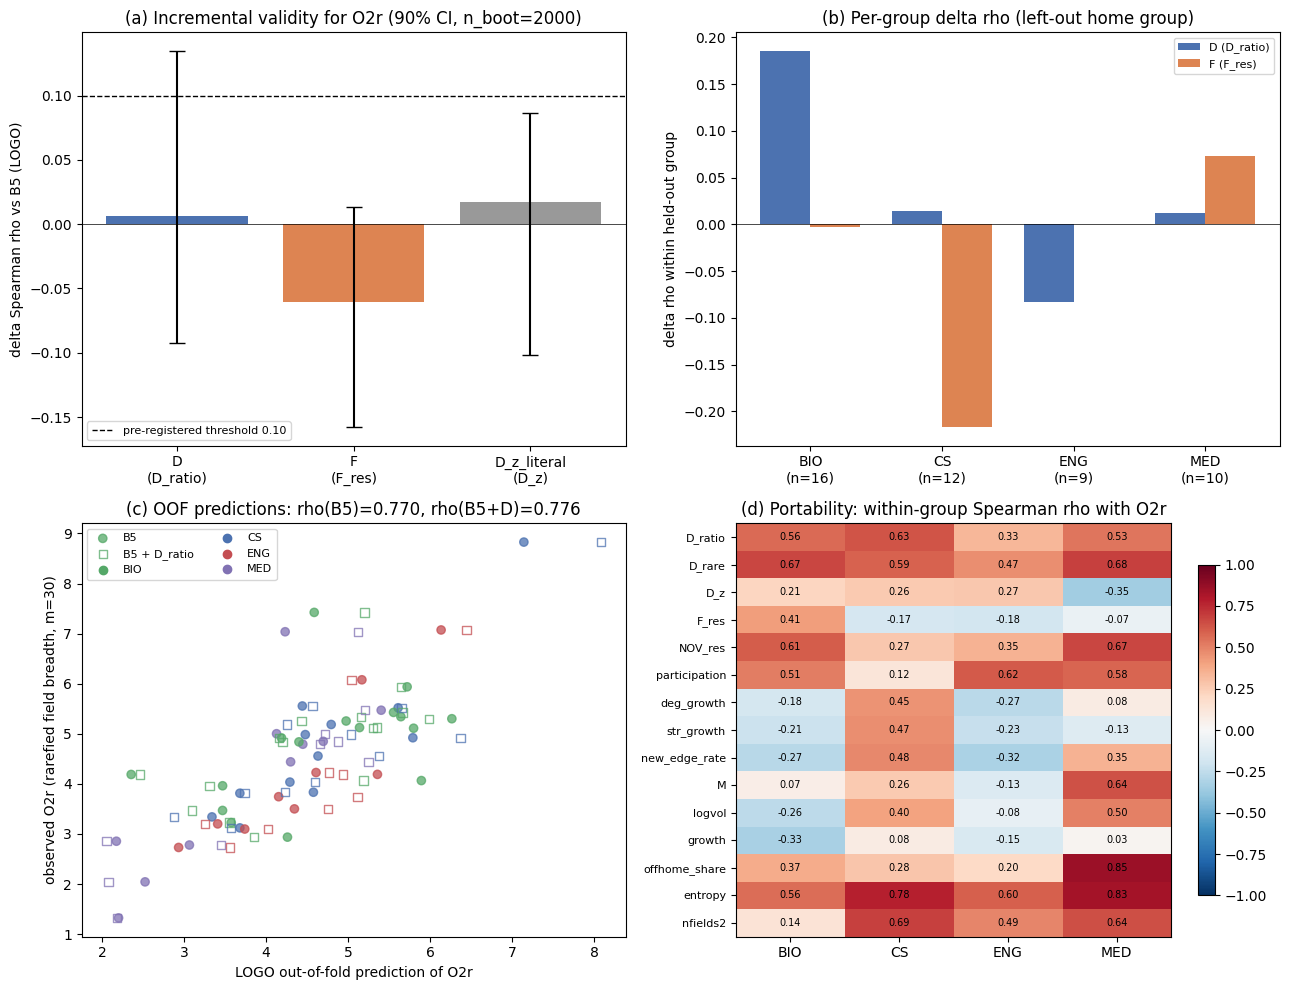

In [19]:
ref = data["reference_screen_result_full_run"]
rows = []
for key in ("D", "F", "D_z_literal"):
    c, r = result["candidates"][key], ref["candidates"][key]
    rows.append({"candidate": f"{key} ({c['feature']})",
                 "delta_rho (demo)": round(c["delta_rho"], 4), "delta_rho (full run)": round(r["delta_rho"], 4),
                 "CI90 (demo)": [round(x, 3) for x in c["CI90"]],
                 "CI90 (full run)": [round(x, 3) for x in r["CI90"]],
                 "groups+": f"{c['n_groups_positive']}/{c['n_groups']}",
                 "SB": round(c["reliability"].get("SB_median", float("nan")), 3),
                 "survives": c["survives"]})
summary = pd.DataFrame(rows)
print(f"B5 baseline LOGO rho(O2r): demo {result['base_metrics']['O2r']:.4f}   full run {ref['base_metrics']['O2r']:.4f}")
print(f"n_boot: demo {result['n_boot']}   full run {ref['n_boot']}")
print("carried forward:", result["carried_forward"], "  survivors:", result["survivors"])
print()
print(summary.to_string(index=False))
print("\nfailed criteria:")
for key in ("D", "F"):
    print(f"  {key}:", [k for k, v in result["candidates"][key]["criteria"].items() if not v])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
# (a) delta-rho with CI90
ax = axes[0, 0]
keys = ["D", "F", "D_z_literal"]
dr = [result["candidates"][k]["delta_rho"] for k in keys]
lo = [result["candidates"][k]["CI90"][0] for k in keys]
hi = [result["candidates"][k]["CI90"][1] for k in keys]
yerr = np.array([[d - l if l == l else 0 for d, l in zip(dr, lo)], [h - d if h == h else 0 for d, h in zip(dr, hi)]])
ax.bar(range(3), dr, yerr=yerr, capsize=6, color=["#4C72B0", "#DD8452", "#999999"])
ax.axhline(0.10, ls="--", color="k", lw=1, label="pre-registered threshold 0.10")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(range(3), [f"{k}\n({result['candidates'][k]['feature']})" for k in keys])
ax.set_ylabel("delta Spearman rho vs B5 (LOGO)")
ax.set_title(f"(a) Incremental validity for O2r (90% CI, n_boot={result['n_boot']})")
ax.legend(loc="lower left", fontsize=8)
# (b) per-group delta-rho
ax = axes[0, 1]
grps = result["portability"]["groups"]
w = 0.38
for i, (k, col) in enumerate([("D", "#4C72B0"), ("F", "#DD8452")]):
    pgd = result["candidates"][k]["per_group_delta_rho"]
    ax.bar(np.arange(len(grps)) + (i - 0.5) * w, [pgd[g] for g in grps], w, label=f"{k} ({PRIMARY[k]})", color=col)
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(range(len(grps)), [f"{g}\n(n={int((main_df.group == g).sum())})" for g in grps])
ax.set_ylabel("delta rho within held-out group")
ax.set_title("(b) Per-group delta rho (left-out home group)")
ax.legend(fontsize=8)
# (c) OOF predictions vs observed O2r
ax = axes[1, 0]
oof = result["_oof"]
y_obs = main_df.set_index("concept").loc[oof["index"], "O2r"].to_numpy(float)
gcol = {"BIO": "#55A868", "CS": "#4C72B0", "ENG": "#C44E52", "MED": "#8172B3"}
gg_ = main_df.set_index("concept").loc[oof["index"], "group"].to_numpy()
ax.scatter(oof["base"], y_obs, c=[gcol[g] for g in gg_], marker="o", alpha=0.75, label="B5")
ax.scatter(oof["D_ratio"], y_obs, facecolors="none", edgecolors=[gcol[g] for g in gg_], marker="s", alpha=0.75,
           label="B5 + D_ratio")
for g, cc in gcol.items():
    ax.scatter([], [], c=cc, label=g)
ax.set_xlabel("LOGO out-of-fold prediction of O2r")
ax.set_ylabel("observed O2r (rarefied field breadth, m=30)")
ax.set_title(f"(c) OOF predictions: rho(B5)={result['base_metrics']['O2r']:.3f}, "
             f"rho(B5+D)={result['base_metrics']['O2r'] + result['candidates']['D']['delta_rho']:.3f}")
ax.legend(fontsize=8, ncol=2)
# (d) portability heatmap
ax = axes[1, 1]
show = ["D_ratio", "D_rare", "D_z", "F_res", "NOV_res", "participation", "deg_growth", "str_growth",
        "new_edge_rate", "M"] + B5
show = [s for s in show if s in result["portability"]["indicators"]]
mat = np.array([[result["portability"]["indicators"][s]["within_group_rho_O2r"][g] for g in grps] for s in show])
im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(grps)), grps)
ax.set_yticks(range(len(show)), show, fontsize=8)
for i in range(len(show)):
    for j in range(len(grps)):
        if np.isfinite(mat[i, j]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("(d) Portability: within-group Spearman rho with O2r")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()